### Импорты:

In [46]:
# --- Базовые библиотеки для работы с данными ---
import pandas as pd                  # Библиотека Pandas: загрузка, очистка и обработка табличных данных
import numpy as np                   # Библиотека NumPy: математические операции и работа с массивами
import scipy.stats as stats          # Модуль stats из SciPy: статистические тесты (в т.ч. проверка на нормальность)

# --- Библиотеки для визуализации данных ---
import matplotlib.pyplot as plt      # Модуль pyplot из Matplotlib: создание базовых графиков и гистограмм
import seaborn as sns                # Библиотека Seaborn: продвинутые статистические графики (тепловые карты и др.)
import plotly.express as px          # Модуль express из Plotly: создание интерактивных графиков

# --- Служебные настройки Python ---
import warnings
warnings.filterwarnings("ignore")    # Игнорирование предупреждений (warnings) для чистоты вывода

# --- Библиотека Scikit-Learn (Инструменты машинного обучения) ---
from sklearn.model_selection import train_test_split          # Модуль model_selection: разделение данных на train и test
from sklearn.preprocessing import LabelEncoder                # Модуль preprocessing: кодирование категориальных меток в числа (0, 1)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # Модуль discriminant_analysis: модель LDA
from sklearn.metrics import accuracy_score                    # Модуль metrics: расчет точности (Accuracy)
from sklearn.metrics import classification_report, confusion_matrix # Модуль матрицы ошибок
from sklearn.model_selection import cross_val_score # Модуль проверки Кросс-валидации
from sklearn.preprocessing import StandardScaler # Модуль для приведения признаков к единому масштабу.
from sklearn.cluster import KMeans # Из модуля cluster библиотеки scikit-learn импортируем класс KMeans для кластеризации
from sklearn.cluster import AgglomerativeClustering # импортируем агломеративную кластеризацию
from scipy.cluster.hierarchy import dendrogram, linkage # Импортируем функции для построения дендрограммы из библиотеки SciPy

### Задание 1:

<div class="alert alert-info">
<b>Определение типа популяции опоссумов по их размерам:</b>

<p>Попробуем определить тип популяции опоссумов по их размерам. Для работы используйте набор данных <code>possum.csv</code>.</p>

- <b>Описание датасета:</b>
1. <b>case:</b> номер наблюдения (observation number)
2. <b>site:</b> номер участка, где был пойман опоссум (site number where trapped)
3. <b>Pop:</b> популяция — Vic (Виктория) или other (Новый Южный Уэльс или Квинсленд)
4. <b>sex:</b> пол — m (самец) или f (самка)
5. <b>age:</b> возраст (age)
6. <b>hdlngth:</b> длина головы, мм (head length)
7. <b>skullw:</b> ширина черепа, мм (skull width)
8. <b>totlngth:</b> общая длина, см (total length)
9. <b>taill:</b> длина хвоста, см (tail length)
10. <b>footlgth:</b> длина стопы (foot length)
11. <b>earconch:</b> длина ушной раковины (ear conch length)
12. <b>eye:</b> расстояние от медиального до латерального угла правого глаза (eye distance)
13. <b>chest:</b> обхват груди, см (chest girth)
14. <b>belly:</b> обхват живота, см (belly girth)

- <b>Для выполнения задания:</b>
1. Выберите и оставьте числовые признаки, по которым будете определять тип животных, и целевую переменную — <b>Pop</b>
2. Закодируйте значения по столбцу <b>Pop</b> в 0 и 1 (можно использовать метод <code>LabelEncoder</code>)
3. Разделите данные на выборку для обучения и тестирования (в соотношении 80% — тренировочная, 20% — тестовая)
4. Постройте модель LDA
5. Рассчитайте точность вашей модели на тестовой выборке

</div>

In [2]:
# чтение файла
df = pd.read_csv('possum.csv')
df

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [3]:
# инфа о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


In [4]:
# удаление не числовую колонку пола и номер наблюдения:
df_pos = df[['site', 'Pop', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']]
df_pos

,site,Pop,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,Vic,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,Vic,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,Vic,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,Vic,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,Vic,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...
99,7,other,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,7,other,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,7,other,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,7,other,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [5]:
# проверка пропусков
print(df_pos.isnull().sum())

site        0
Pop         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [6]:
# проверка дубликатов:
df_pos.duplicated().sum()

np.int64(0)

у нас достаточно небольшое колличество пропусков и отсутствуют дубликаты. Пропуски удаляются, для корректного обучения модели

In [7]:
df_pos = df_pos.dropna()
df_pos

,site,Pop,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,Vic,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,Vic,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,Vic,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,Vic,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,Vic,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...
99,7,other,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,7,other,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,7,other,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,7,other,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [8]:
# Проверяем, что пропусков больше нет
print(df_pos.isnull().sum())

site        0
Pop         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64


пропуски удалены можем приступать к дальнейшей работе

In [9]:
# 2. Создаем объект LabelEncoder и кодируем Pop в 0 и 1
le = LabelEncoder()
# Метод fit_transform обучает энкодер и сразу преобразует данные
df_pos['Pop_encoded'] = le.fit_transform(df_pos['Pop'])

# 3. Формируем X (все числовые признаки) и y (закодированный Pop)
X = df_pos.drop(columns=['Pop', 'Pop_encoded'])
y = df_pos['Pop_encoded']

In [10]:
# print(le.classes_)

In [11]:
# le.inverse_transform([0, 1, 0])

In [12]:
# 1. Разделяем выборку на train (80%) и test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. Инициализируем и обучаем модель LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 3. Делаем предсказание на тестовой выборке
y_pred = lda.predict(X_test)

# 4. Рассчитываем и выводим метрику Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy модели LDA на тестовой выборке: {acc:.4f}')

Accuracy модели LDA на тестовой выборке: 1.0000


In [13]:
# Посмотрим на вклад каждого признака в решение модели
importance = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': lda.coef_[0]
}).sort_values(by='Коэффициент', key=abs, ascending=False)

print(importance)

     Признак  Коэффициент
0       site     6.541059
7   earconch    -4.123784
5      taill     2.468250
6   footlgth    -1.686696
2    hdlngth     1.255016
8        eye     1.221088
1        age    -0.921668
3     skullw     0.514904
10     belly     0.184325
4   totlngth    -0.095856
9      chest    -0.076078


In [14]:
# Исключаем site из признаков
X_no_site = df_pos.drop(columns=['Pop', 'Pop_encoded', 'site'])

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_site, y, test_size=0.2, random_state=42, stratify=y
)

lda_ns = LinearDiscriminantAnalysis()
lda_ns.fit(X_train_ns, y_train_ns)
print("Accuracy без site:", accuracy_score(y_test_ns, lda_ns.predict(X_test_ns)))

Accuracy без site: 1.0


In [15]:
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))

print("\nПодробный отчет по метрикам:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Матрица ошибок:
[[ 9  0]
 [ 0 12]]

Подробный отчет по метрикам:
              precision    recall  f1-score   support

         Vic       1.00      1.00      1.00         9
       other       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [16]:
# Оценка модели на 5 фолдах
scores = cross_val_score(LinearDiscriminantAnalysis(), X, y, cv=5)

print(f"Точность на каждом фолде: {scores}")
print(f"Средняя точность (Mean Accuracy): {scores.mean():.4f}")

Точность на каждом фолде: [1. 1. 1. 1. 1.]
Средняя точность (Mean Accuracy): 1.0000


### Задание 2:

<div class="alert alert-info">
<b>Кластеризация стран на основе показателей импорта и экспорта:</b>

<p>Теперь кластеризируем страны на основании показателей импорта и экспорта. Для работы используйте набор данных <code>Country-data.csv</code>.</p>

- <b>Описание датасета:</b>
1. <b>country:</b> название страны (Name of the country)
2. <b>child_mort:</b> смертность детей до 5 лет на 1000 рожденных (child mortality under 5)
3. <b>exports:</b> экспорт товаров и услуг на душу населения в % от ВВП на душу населения (exports per capita)
4. <b>health:</b> общие расходы на здравоохранение на душу населения в % от ВВП на душу населения (health spending)
5. <b>imports:</b> импорт товаров и услуг на душу населения в % от ВВП на душу населения (imports per capita)
6. <b>income:</b> чистый доход на человека (net income per person)
7. <b>inflation:</b> годовой темп роста ВВП / инфляция (inflation rate)
8. <b>life_expec:</b> средняя продолжительность жизни новорожденного (life expectancy)
9. <b>total_fer:</b> суммарный коэффициент рождаемости на одну женщину (total fertility)
10. <b>gdpp:</b> ВВП на душу населения (GDP per capita)

- <b>Для выполнения задания:</b>
1. Выберите и оставьте только те признаки, по которым будете проводить кластерный анализ
2. Подберите оптимальное число кластеров для алгоритма K-means
3. Визуализируйте полученную кластеризацию
4. Проверьте правильность выбора кластеров с помощью метода локтя (Elbow Method)
5. Примените агломеративную кластеризацию (Agglomerative Clustering) с учётом рассчитанного оптимального количества кластеров
6. Визуализируйте результат

</div>

In [17]:
df_country = pd.read_csv('country-data.csv')
df_country

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [18]:
df_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [19]:
df_country.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [20]:
df_country.duplicated().sum()

np.int64(0)

In [23]:
# Создаем новый датафрейм, оставляя только страны и ключевые показатели
df_clusters = df_country[['country', 'exports', 'imports']].copy()
df_clusters

,country,exports,imports
0,Afghanistan,10.0,44.9
1,Albania,28.0,48.6
2,Algeria,38.4,31.4
3,Angola,62.3,42.9
4,Antigua and Barbuda,45.5,58.9
...,...,...,...
162,Vanuatu,46.6,52.7
163,Venezuela,28.5,17.6
164,Vietnam,72.0,80.2
165,Yemen,30.0,34.4


In [25]:
# Выбираем признаки для кластеризации
X_country = df_clusters[['exports', 'imports']]
df_clusters.head()

,country,exports,imports
0,Afghanistan,10.0,44.9
1,Albania,28.0,48.6
2,Algeria,38.4,31.4
3,Angola,62.3,42.9
4,Antigua and Barbuda,45.5,58.9


#### Масштабирование признаков (Feature Scaling)

In [28]:
# 1. Создаем экземпляр класса-масштабировщика
scaler = StandardScaler()

'''
2. Обучаем масштабировщик на наших данных и сразу трансформируем их, где
- fit рассчитывает среднее значение (mean) и стандартное отклонение (std) для каждого столбца;
- transform преобразует значения по формуле: (x - mean) / std.
На выходе получаем двумерный массив NumPy (NumPy array)
'''
X_scaled = scaler.fit_transform(X_country)

# Проверим форму (shape) полученного массива: (количество стран, количество признаков)
print("Размерность масштабированной матрицы:", X_scaled.shape)

Размерность масштабированной матрицы: (167, 2)


#### определение оптимального k-mean

In [32]:
# 1. Создаем пустой список, куда будем сохранять значения инерции для каждого k
inertia = []

# 2. Задаем диапазон исследуемого количества кластеров от 1 до 10 включительно
K_range = range(1, 11)

# 3. В цикле обучаем модель K-Means для каждого значения k
for k in K_range:
    # n_clusters=k — задаем текущее число кластеров
    # random_state=42 — фиксируем случайный выбор начальных центроидов для воспроизводимости
    # n_init=10 — заставляем алгоритм запуститься 10 раз с разными центроидами,
    # чтобы найти лучшую инерцию и не застрять в локальном минимуме
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Обучаем модель на наших МАСШТАБИРОВАННЫХ данных (X_scaled)
    kmeans.fit(X_scaled)

    # Считываем значение атрибута inertia_ и добавляем его в наш список
    inertia.append(kmeans.inertia_)

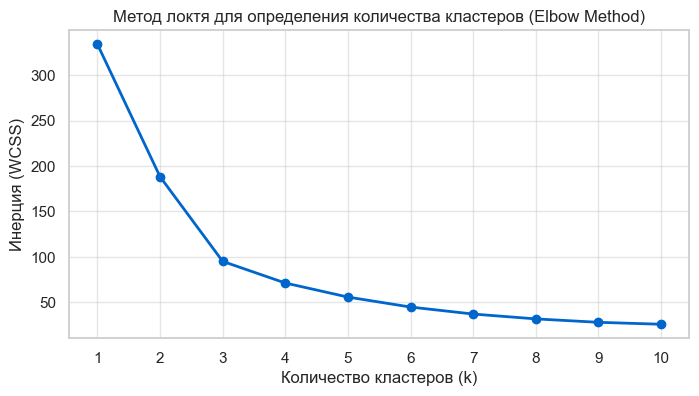

In [35]:
# Визуализируем полученные результаты (График метода локтя)
# Задаем стиль
sns.set_theme(style='whitegrid')

# Задаем размер фигуры (ширина 8 дюймов, высота 4 дюйма)
plt.figure(figsize=(8, 4))

# Рисуем график: по оси X — K_range, по оси Y — inertia
# marker='o' добавляет точки на линию, linewidth=2 задает толщину линии
plt.plot(K_range, inertia, marker='o', color='#0066cc', linewidth=2)

# Добавляем названия графика и осей
plt.title('Метод локтя для определения количества кластеров (Elbow Method)')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция (WCSS)')

# Настраиваем деления по оси X strictly от 1 до 10
plt.xticks(K_range)

# Включаем координатную сетку для удобства считывания изгиба
plt.grid(True)

# Отображаем график
plt.show()

основной перелом графика из резкого падения в более плавное происходит на k=3. Поэтому для Обучения K-Means выбираем ($k = 3$) и визуализируем

In [38]:
# 1. Инициализируем модель K-Means с оптимальным k = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Обучаем модель и получаем метки кластеров для каждой страны (от 0 до 2)
# fit_predict делает fit() и сразу возвращает вектор предсказанных кластеров
clusters_kmeans = kmeans.fit_predict(X_scaled)

# 3. Добавляем колонку с меткой кластера в наш рабочий датафрейм
df_clusters['kmeans_cluster'] = clusters_kmeans

# 4. Переводим центроиды кластеров обратно в оригинальный масштаб (% от ВВП)
# Метод inverse_transform класса scaler возвращает исходные значения импорта и экспорта
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

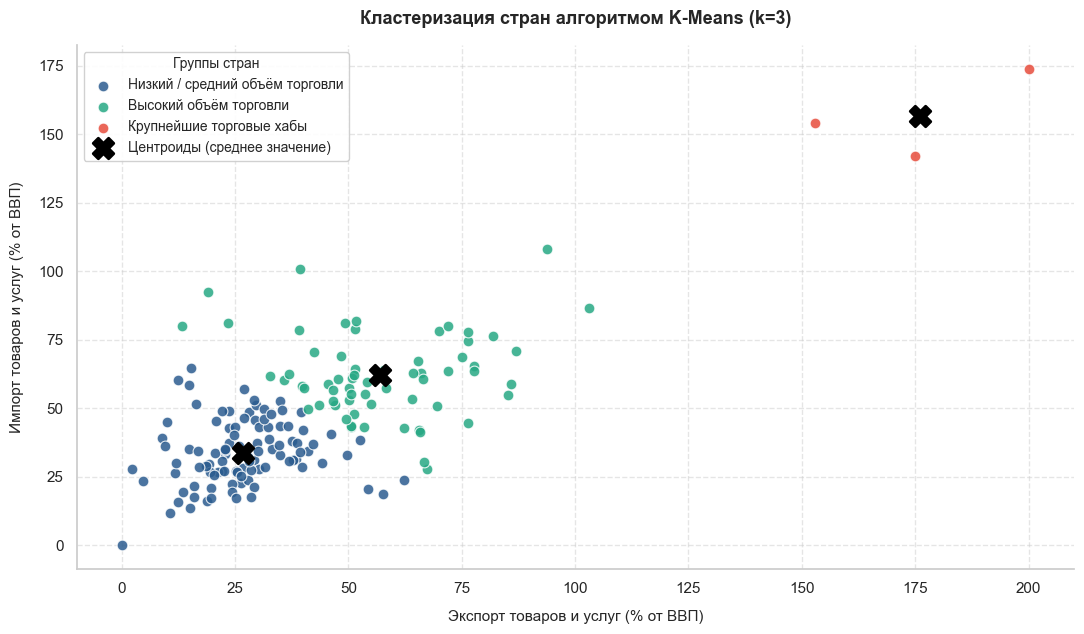

In [40]:
# Задаем размер фигуры
plt.figure(figsize=(11, 6.5), dpi=100)

# Словарь с понятными названиями кластеров и фиксированными цветами
cluster_names = {
    0: 'Низкий / средний объём торговли',
    1: 'Высокий объём торговли',
    2: 'Крупнейшие торговые хабы'
}
colors = ['#2b5c8f', '#27a884', '#e74c3c']

# 1. Отрисовываем каждый кластер отдельно, чтобы сформировать понятную легенду
for cluster_id in range(3):
    cluster_data = df_clusters[df_clusters['kmeans_cluster'] == cluster_id]
    plt.scatter(
        cluster_data['exports'],
        cluster_data['imports'],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        s=60,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.8
    )

# 2. Отрисовываем центроиды кластеров
plt.scatter(
    centroids_orig[:, 0],
    centroids_orig[:, 1],
    c='black',
    marker='X',
    s=220,
    linewidths=2,
    label='Центроиды (среднее значение)',
    zorder=5
)

# 3. Настройка заголовков и осей
plt.title('Кластеризация стран алгоритмом K-Means (k=3)', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Экспорт товаров и услуг (% от ВВП)', fontsize=11, labelpad=10)
plt.ylabel('Импорт товаров и услуг (% от ВВП)', fontsize=11, labelpad=10)

# 4. Настройка сетки и легенды
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Группы стран', title_fontsize='10', fontsize=10, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

# Убираем рамки сверху и справа
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [41]:
# Создаем интерактивный точечный график
fig = px.scatter(
    df_clusters,
    x='exports',
    y='imports',
    color='kmeans_cluster',
    hover_name='country',  # <--- Показывает название страны при наведении!
    title='Интерактивная кластеризация K-Means (k=3)',
    labels={'exports': 'Экспорт (% от ВВП)', 'imports': 'Импорт (% от ВВП)', 'kmeans_cluster': 'Кластер'},
    template='plotly_white'
)

fig.show()

#### Применяем алгомеративную кластеризацию с учётом рассчитанного методом локтя оптимального количества кластеров k=3.

In [43]:
# 1. Инициализируем модель агломеративной кластеризации для k = 3
# linkage='ward' (по умолчанию) минимизирует сумму квадратных отклонений внутри объединяемых кластеров
agglom = AgglomerativeClustering(n_clusters=3)

# 2. Обучаем модель на наших МАСШТАБИРОВАННЫХ данных (X_scaled) и получаем метки кластеров
clusters_agglom = agglom.fit_predict(X_scaled)

# 3. Сохраняем метки в наш датафрейм в новую колонку 'agglom_cluster'
df_clusters['agglom_cluster'] = clusters_agglom

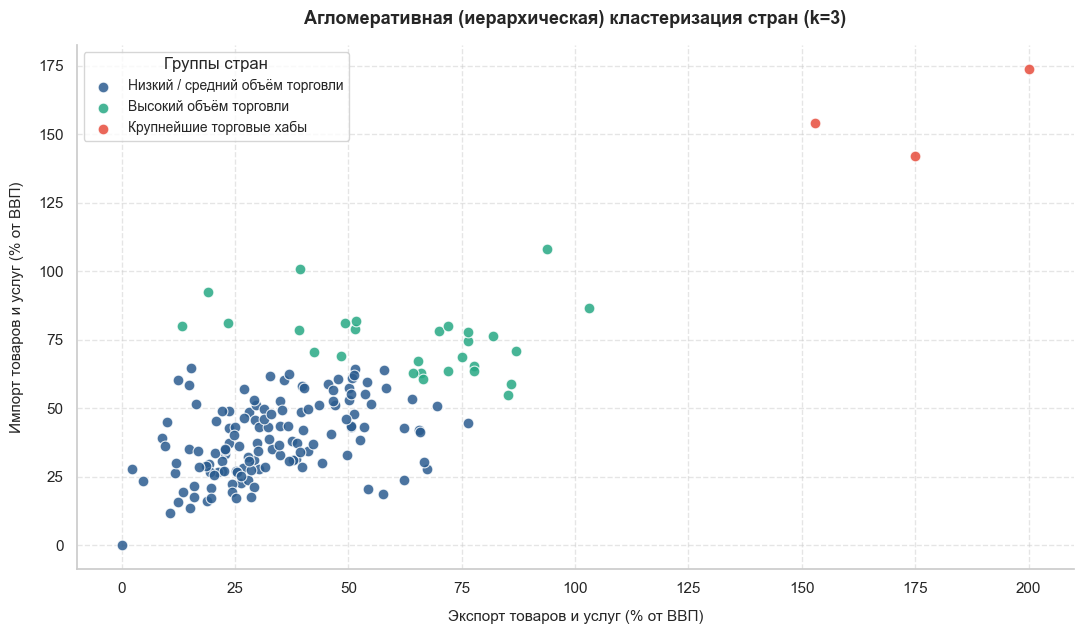

In [44]:
#Аккуратное оформление статичного графика (Matplotlib)
plt.figure(figsize=(11, 6.5), dpi=100)

cluster_names = {
    0: 'Низкий / средний объём торговли',
    1: 'Высокий объём торговли',
    2: 'Крупнейшие торговые хабы'
}
colors = ['#2b5c8f', '#27a884', '#e74c3c']

# Отрисовываем каждый кластер отдельно для красивой легенды
for cluster_id in range(3):
    cluster_data = df_clusters[df_clusters['agglom_cluster'] == cluster_id]
    plt.scatter(
        cluster_data['exports'],
        cluster_data['imports'],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        s=60,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.8
    )

# Настройка заголовков и осей
plt.title('Агломеративная (иерархическая) кластеризация стран (k=3)', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Экспорт товаров и услуг (% от ВВП)', fontsize=11, labelpad=10)
plt.ylabel('Импорт товаров и услуг (% от ВВП)', fontsize=11, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Группы стран', fontsize=10, loc='upper left', frameon=True)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
fig_agglom = px.scatter(
    df_clusters,
    x='exports',
    y='imports',
    color='agglom_cluster',
    hover_name='country',
    title='Интерактивная Агломеративная кластеризация (k=3)',
    labels={'exports': 'Экспорт (% от ВВП)', 'imports': 'Импорт (% от ВВП)', 'agglom_cluster': 'Кластер'},
    template='plotly_white'
)

fig_agglom.show()

#### Сингапур, Люксембург и Мальта имеют аномально высокие значение экспорта и импорта по сравнению с другими странами. Уже здесь видно что это крупнейшие торговые хабы мира

Дендрограмма для наглядности работы метода

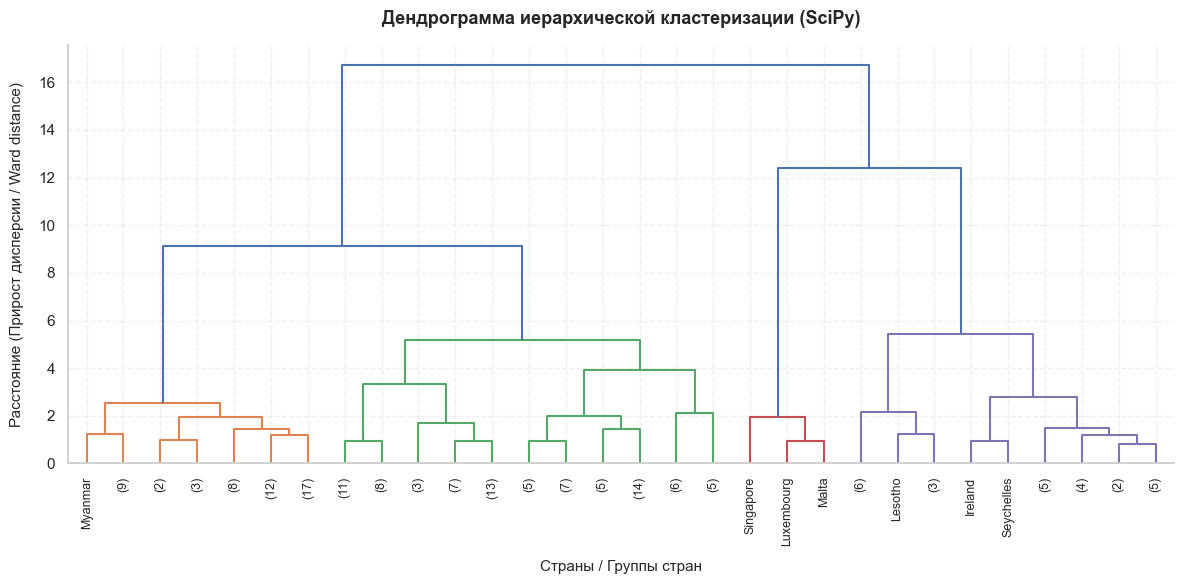

In [47]:
# 1. Строим матрицу связей (linkage matrix) с помощью метода Варда ('ward')
# Она содержит всю историю слияний точек на основе масштабированных данных X_scaled
Z = linkage(X_scaled, method='ward')

# 2. Отрисовываем дендрограмму
plt.figure(figsize=(12, 6), dpi=100)

dendrogram(
    Z,
    labels=df_clusters['country'].values,  # Подписываем страны на нижней оси
    truncate_mode='lastp',                 # Показываем последние p объединений, чтобы график не перегружался
    p=30,                                  # Показать 30 финальных веток
    leaf_rotation=90,                      # Поворот подписей на 90 градусов
    leaf_font_size=9,
    color_threshold=8                      # Цветной порог для разделения на кластеры
)

plt.title('Дендрограмма иерархической кластеризации (SciPy)', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Страны / Группы стран', fontsize=11, labelpad=10)
plt.ylabel('Расстояние (Прирост дисперсии / Ward distance)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### интерпритация результатов:

In [48]:
# Считаем таблицу сопряженности (Cross-tabulation)
ct = pd.crosstab(df_clusters['kmeans_cluster'], df_clusters['agglom_cluster'],
                 rownames=['K-Means'], colnames=['Agglomerative'])
print("Таблица сравнения меток кластеров:")
print(ct)

Таблица сравнения меток кластеров:
Agglomerative    0   1  2
K-Means                  
0              100   0  0
1               36  28  0
2                0   0  3


In [49]:
# Группируем датасет по кластерам K-Means и считаем средний экспорт, импорт и количество стран
cluster_summary = df_clusters.groupby('kmeans_cluster').agg(
    count=('country', 'count'),
    mean_exports=('exports', 'mean'),
    mean_imports=('imports', 'mean')
).reset_index()

# Переименуем кластеры для понятности
cluster_summary['description'] = [
    'Низкий/средний объём торговли',
    'Высокий объём торговли',
    'Крупнейшие торговые хабы'
]

print("\nИтоговое описание кластеров:")
print(cluster_summary[['description', 'count', 'mean_exports', 'mean_imports']])


Итоговое описание кластеров:
                     description  count  mean_exports  mean_imports
0  Низкий/средний объём торговли    100     26.842990     33.845659
1         Высокий объём торговли     64     57.076563     62.126562
2       Крупнейшие торговые хабы      3    176.000000    156.666667
